In [ ]:
print("2. ОПИСАНИЕ ДАТАСЕТА")
print("""
Предметная область: Биология, экология, зоология

Источник данных: Данные собраны доктором Кристен Горман и командой Палмер ЛТЭР
в Антарктике. Реальные данные наблюдений.

Характер данных: Реальные полевые данные

Атрибуты датасета:
1. species (вид) - категориальный: Adelie, Chinstrap, Gentoo
2. island (остров) - категориальный: Torgersen, Biscoe, Dream
3. bill_length_mm (длина клюва) - числовой: в миллиметрах
4. bill_depth_mm (глубина клюва) - числовой: в миллиметрах
5. flipper_length_mm (длина плавника) - числовой: в миллиметрах
6. body_mass_g (масса тела) - числовой: в граммах
7. sex (пол) - категориальный: male, female
8. year (год) - числовой: год наблюдения (2007, 2008, 2009)

Задача анализа:
Классификация вида пингвина по морфометрическим характеристикам
и кластеризация на основе физических параметров.
""")

2. ОПИСАНИЕ ДАТАСЕТА

Предметная область: Биология, экология, зоология

Источник данных: Данные собраны доктором Кристен Горман и командой Палмер ЛТЭР 
в Антарктике. Реальные данные наблюдений.

Характер данных: Реальные полевые данные

Атрибуты датасета:
1. species (вид) - категориальный: Adelie, Chinstrap, Gentoo
2. island (остров) - категориальный: Torgersen, Biscoe, Dream  
3. bill_length_mm (длина клюва) - числовой: в миллиметрах
4. bill_depth_mm (глубина клюва) - числовой: в миллиметрах
5. flipper_length_mm (длина плавника) - числовой: в миллиметрах
6. body_mass_g (масса тела) - числовой: в граммах
7. sex (пол) - категориальный: male, female
8. year (год) - числовой: год наблюдения (2007, 2008, 2009)

Задача анализа: 
Классификация вида пингвина по морфометрическим характеристикам
и кластеризация на основе физических параметров.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Импорт данных
df = sns.load_dataset('penguins')

3. АНАЛИЗ КАЖДОГО АТРИБУТА
bill_length_mm: Выбросы - 0
bill_depth_mm: Выбросы - 0
flipper_length_mm: Выбросы - 0
body_mass_g: Выбросы - 0

Статистика по числовым атрибутам:
                   Среднее     СКО Пропуски Обработка пропусков
bill_length_mm       43.92    5.46        2   Замена на медиану
bill_depth_mm        17.15    1.97        2   Замена на медиану
flipper_length_mm   200.92   14.06        2   Замена на медиану
body_mass_g        4201.75  801.95        2   Замена на медиану


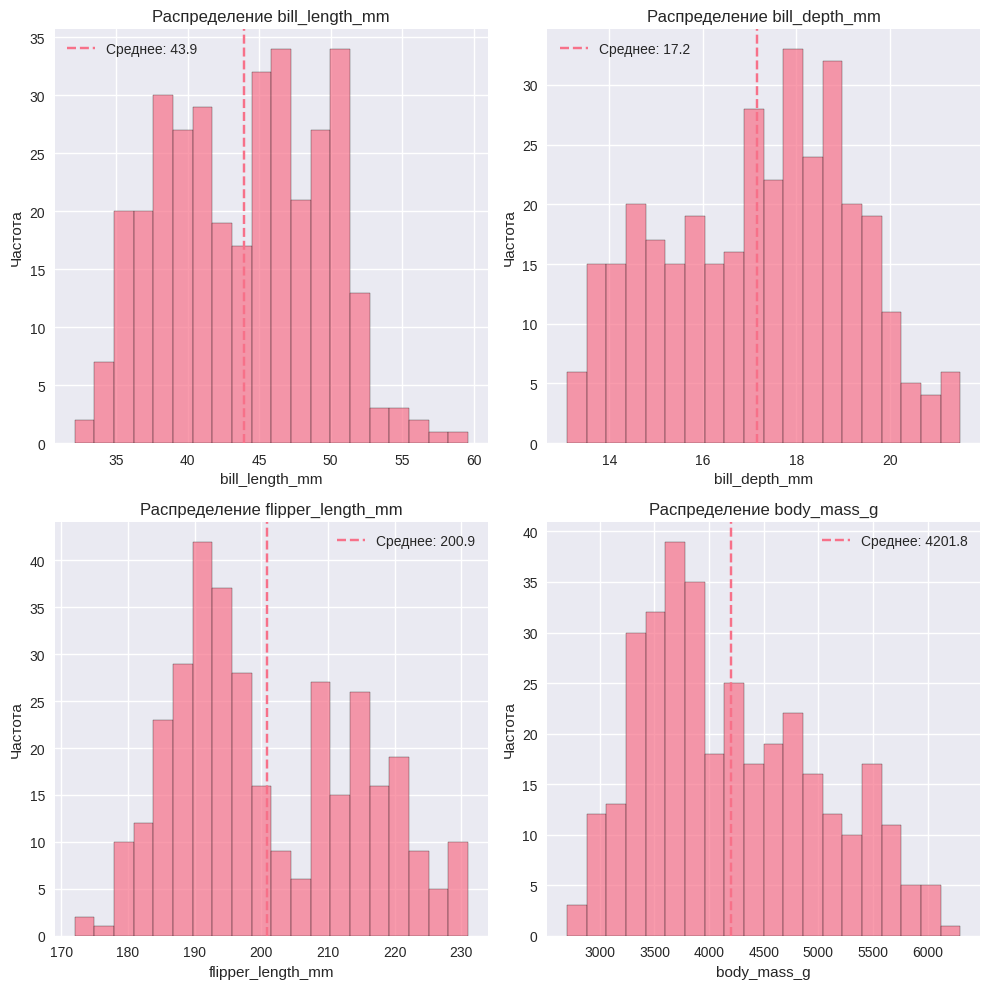

In [ ]:
print("3. АНАЛИЗ КАЖДОГО АТРИБУТА")

#Выбираем только числовые атрибуты для детального анализа
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

#Создаем таблицу для статистики
stats_df = pd.DataFrame(index=numeric_cols, columns=['Среднее', 'СКО', 'Пропуски', 'Обработка пропусков'])

#Создаем гистограммы
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    mean_val = df[col].mean()
    std_val = df[col].std()
    missing = df[col].isnull().sum()

    stats_df.loc[col] = [
        f"{mean_val:.2f}",
        f"{std_val:.2f}",
        f"{missing}",
        "Замена на медиану" if missing > 0 else "Не требуется"
    ]

    #Гистограмма
    ax = axes[i]
    df[col].hist(ax=ax, bins=20, edgecolor='black', alpha=0.7)
    ax.axvline(mean_val, linestyle='--', label=f'Среднее: {mean_val:.1f}')
    ax.set_title(f'Распределение {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Частота')
    ax.legend()

    #Проверка на выбросы
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: Выбросы - {len(outliers)}")

print("\nСтатистика по числовым атрибутам:")
print(stats_df)

plt.tight_layout()
plt.show()


АНАЛИЗ КАТЕГОРИАЛЬНЫХ АТРИБУТОВ:

species:
  Пропуски: 0
  Уникальных значений: 3
  Предложение по обработке пропусков: Не требуется

island:
  Пропуски: 0
  Уникальных значений: 3
  Предложение по обработке пропусков: Не требуется

sex:
  Пропуски: 11
  Уникальных значений: 2
  Предложение по обработке пропусков: Замена модой


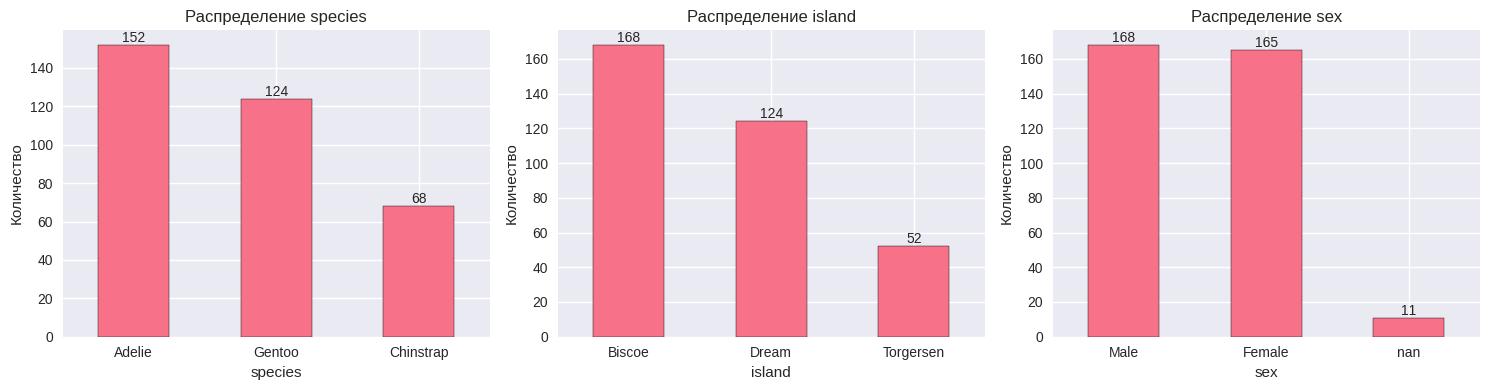

In [ ]:
print("\nАНАЛИЗ КАТЕГОРИАЛЬНЫХ АТРИБУТОВ:")
categorical_cols = ['species', 'island', 'sex']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    missing = df[col].isnull().sum()

    #Распределение значений
    value_counts = df[col].value_counts(dropna=False)

    #Визуализация
    bars = value_counts.plot(kind='bar', ax=ax, edgecolor='black')
    ax.set_title(f'Распределение {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Количество')
    ax.tick_params(axis='x', rotation=0)

    #Добавление значений на столбцы
    for container in bars.containers:
        ax.bar_label(container)

    print(f"\n{col}:")
    print(f"  Пропуски: {missing}")
    print(f"  Уникальных значений: {df[col].nunique()}")
    print(f"  Предложение по обработке пропусков: {'Замена модой' if missing > 0 else 'Не требуется'}")

plt.tight_layout()
plt.show()

4. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ


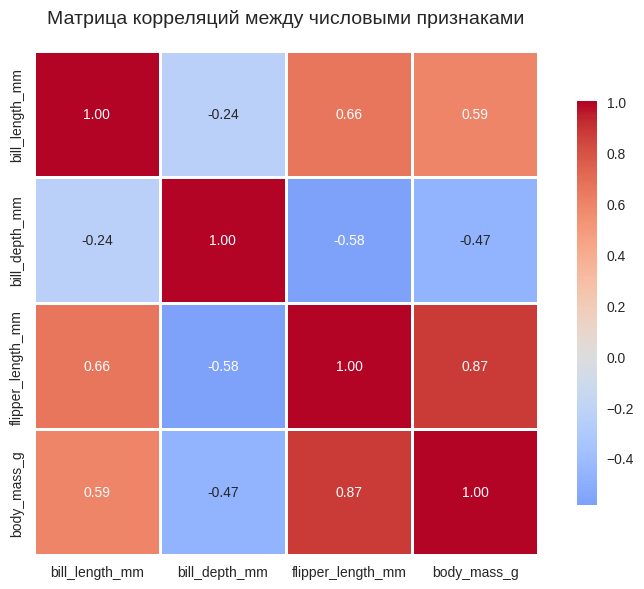

In [ ]:
print("4. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ")

#Создаем числовую матрицу для анализа
numeric_df = df[numeric_cols].copy()

#Заполняем пропуски медианами для корреляционного анализа (без inplace)
for col in numeric_cols:
    numeric_df[col] = numeric_df[col].fillna(numeric_df[col].median())

#Матрица корреляций
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',
            center=0, fmt='.2f', linewidths=1, square=True,
            cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляций между числовыми признаками', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [ ]:
print("Высококоррелированные атрибуты (|corr| > 0.7):")

high_corr_threshold = 0.7
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > high_corr_threshold:
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            print(f"{col1} и {col2}: {corr_value:.3f}")

print("\nАтрибуты без корреляции (|corr| < 0.3):")
low_corr_threshold = 0.3
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) < low_corr_threshold:
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            print(f"{col1} и {col2}: {corr_value:.3f}")

Высококоррелированные атрибуты (|corr| > 0.7):
flipper_length_mm и body_mass_g: 0.871

Атрибуты без корреляции (|corr| < 0.3):
bill_length_mm и bill_depth_mm: -0.235


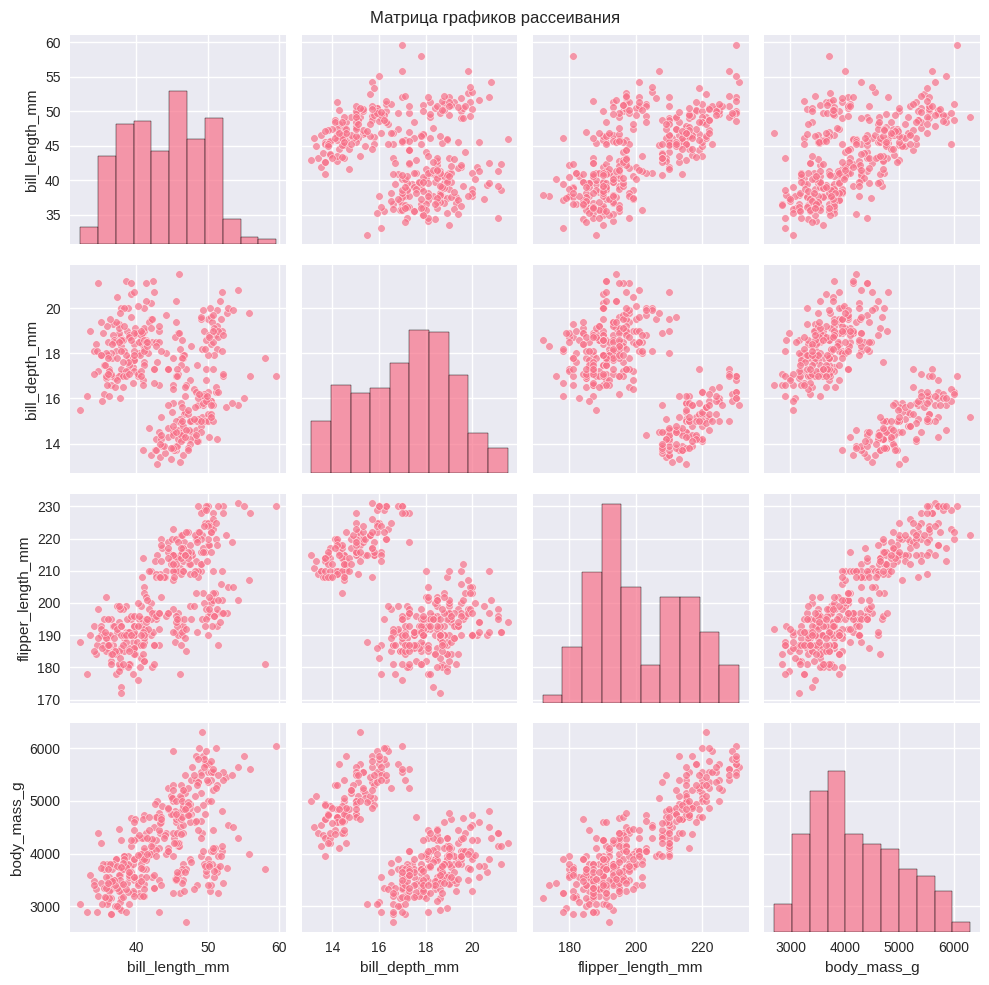

In [ ]:
#Матрица графиков рассеивания
sns.pairplot(numeric_df, diag_kind='hist',
             plot_kws={'alpha': 0.7, 's': 30},
             diag_kws={'alpha': 0.7})
plt.suptitle('Матрица графиков рассеивания')
plt.tight_layout()
plt.show()

In [ ]:
print("5. ВЫВОДЫ")
print("""
   - Наиболее сильная связь: длина плавника и масса тела
   - Пропуски незначительны (2 значения в каждом признаке)
   - Требуется обработка пропусков: числовые - медианой, категориальные - модой
   - Выбросы не обнаружены и не требуют обработки перед кластеризацией
""")

5. ВЫВОДЫ

   - Наиболее сильная связь: длина плавника и масса тела
   - Пропуски незначительны (2 значения в каждом признаке)
   - Требуется обработка пропусков: числовые - медианой, категориальные - модой
   - Выбросы не обнаружены и не требуют обработки перед кластеризацией

